# Working with local raster data using rioxarray

Open a locally stored Sentinel-2 band with `rioxarray`, inspect its attributes and CRS, visualize it at different resolutions, compute statistics, handle missing data, and work with multi-band imagery.

## 1. Load a raster and view its attributes

In [1]:
import rioxarray
rhodes_red = rioxarray.open_rasterio("../data/sentinel2/red.tif")

In [2]:
print(rhodes_red)

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
[120560400 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0


In [3]:
print(rhodes_red.rio.crs)
print(rhodes_red.rio.nodata)
print(rhodes_red.rio.bounds())
print(rhodes_red.rio.width)
print(rhodes_red.rio.height)
print(rhodes_red.rio.resolution())

EPSG:32635
0
(499980.0, 3990240.0, 609780.0, 4100040.0)
10980
10980
(10.0, -10.0)


## 2. Visualize the raster

In [4]:
rhodes_red.values

array([[[ 0,  0,  0, ..., 57, 43, 44],
        [ 0,  0,  0, ..., 61, 24, 19],
        [ 0,  0,  0, ..., 22,  1,  1],
        ...,
        [ 0,  0,  0, ...,  1,  1,  1],
        [ 0,  0,  0, ...,  1,  1,  1],
        [ 0,  0,  0, ...,  1,  1,  1]]],
      shape=(1, 10980, 10980), dtype=uint16)

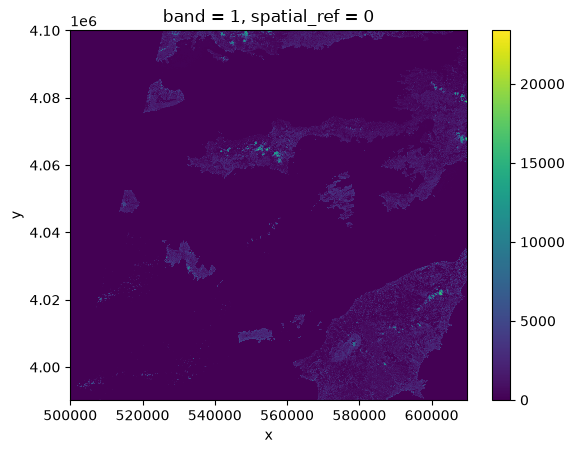

In [5]:
rhodes_red.plot()

## 3. Resample with overview levels

In [7]:
rhodes_red_80 = rioxarray.open_rasterio("../data/sentinel2/red.tif", overview_level=2)
print(rhodes_red_80.rio.resolution())

(79.97086671522214, -79.97086671522214)


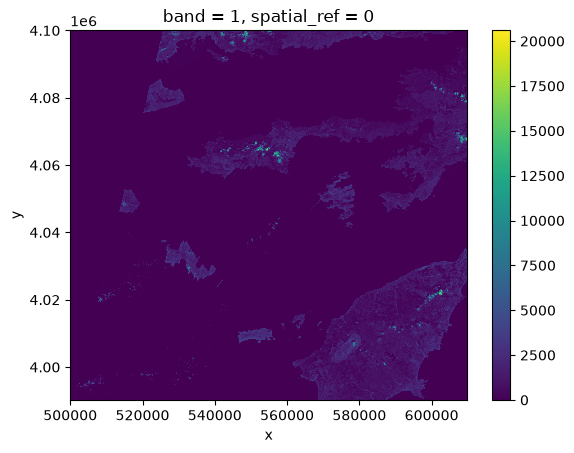

In [8]:
rhodes_red_80.plot()

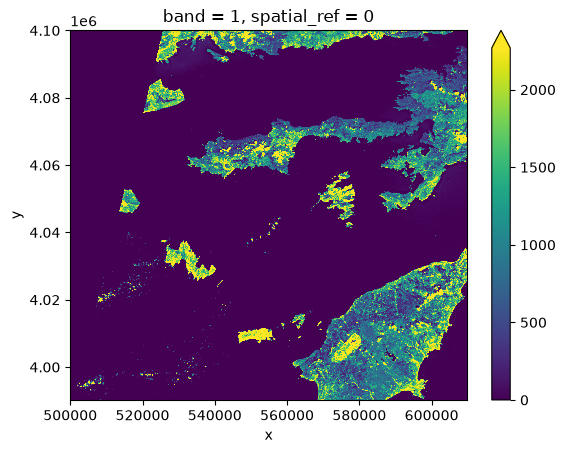

In [9]:
rhodes_red_80.plot(robust=True)

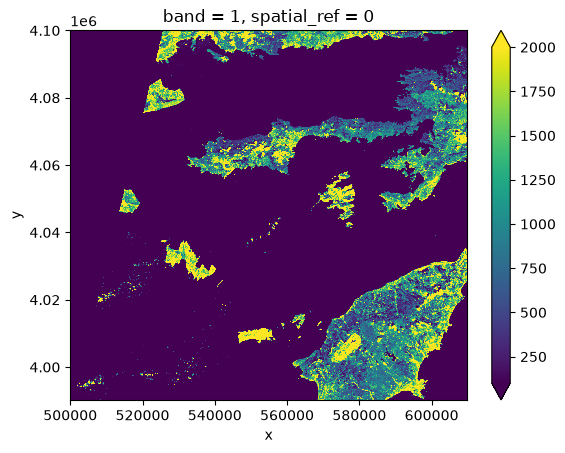

In [10]:
rhodes_red_80.plot(vmin=100, vmax=2000)

## 4. Inspect the coordinate reference system (CRS)

In [11]:
print(rhodes_red_80.rio.crs)

EPSG:32635


In [13]:
rhodes_red_80.rio.crs.to_epsg()

32635

In [14]:
from pyproj import CRS
epsg = rhodes_red_80.rio.crs.to_epsg()
crs = CRS(epsg)
crs

<Projected CRS: EPSG:32635>
Name: WGS 84 / UTM zone 35N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Bulgaria. Central African Republic. Democratic Republic of the Congo (Zaire). Egypt. Estonia. Finland. Greece. Latvia. Lesotho. Libya. Lithuania. Moldova. Norway. Poland. Romania. Russian Federation. Sudan. Svalbard. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (24.0, 0.0, 30.0, 84.0)
Coordinate Operation:
- name: UTM zone 35N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
crs.area_of_use

AreaOfUse(west=24.0, south=0.0, east=30.0, north=84.0, name='Between 24°E and 30°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Bulgaria. Central African Republic. Democratic Republic of the Congo (Zaire). Egypt. Estonia. Finland. Greece. Latvia. Lesotho. Libya. Lithuania. Moldova. Norway. Poland. Romania. Russian Federation. Sudan. Svalbard. Türkiye (Turkey). Uganda. Ukraine.')

## 5. Calculate raster statistics

In [16]:
print(rhodes_red_80.min())
print(rhodes_red_80.max())
print(rhodes_red_80.mean())
print(rhodes_red_80.std())

<xarray.DataArray ()> Size: 2B
array(0, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 2B
array(20598, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 8B
array(294.09450759)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 8B
array(735.51761417)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_off

In [17]:
print(rhodes_red_80.quantile([0.25, 0.75]))

<xarray.DataArray (quantile: 2)> Size: 16B
array([ 1., 54.])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0


In [18]:
import numpy
print(numpy.percentile(rhodes_red_80, 25))
print(numpy.percentile(rhodes_red_80, 75))

1.0
54.0


## 6. Handle missing data

In [19]:
rhodes_red_80.rio.nodata

np.uint16(0)

In [21]:
rhodes_red_mask_80 = rioxarray.open_rasterio("../data/sentinel2/red.tif", masked=True, overview_level=2)

In [22]:
print(rhodes_red_mask_80)

<xarray.DataArray (band: 1, y: 1373, x: 1373)> Size: 8MB
[1885129 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 11kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 11kB 5e+05 5.001e+05 ... 6.097e+05 6.097e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0


In [23]:
rhodes_red_altmask_80 = rhodes_red_80.where(rhodes_red_80!=rhodes_red_80.rio.nodata)

In [24]:
print(rhodes_red_80.min())
print(rhodes_red_mask_80.min())
print(rhodes_red_80.max())
print(rhodes_red_mask_80.max())
print(rhodes_red_80.mean())
print(rhodes_red_mask_80.mean())
print(rhodes_red_80.std())
print(rhodes_red_mask_80.std())

<xarray.DataArray ()> Size: 2B
array(0, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 4B
array(1., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 2B
array(20598, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 4B
array(20598., dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> 

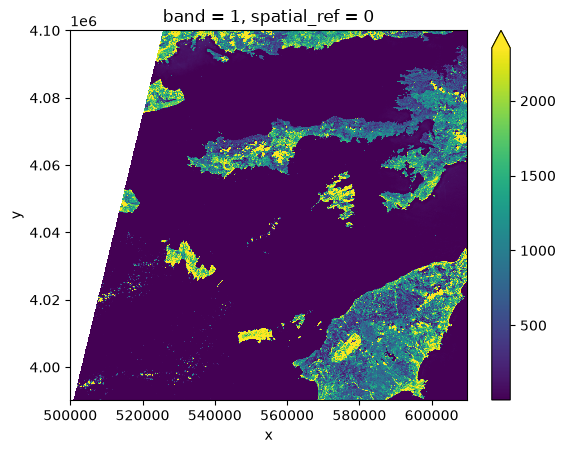

In [25]:
rhodes_red_mask_80.plot(robust=True)

## 7. Work with multiple raster bands

In [26]:
rhodes_visual = rioxarray.open_rasterio('../data/sentinel2/visual.tif', overview_level=2)
rhodes_visual

<xarray.DataArray (band: 3, y: 1373, x: 1373)> Size: 6MB
[5655387 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 11kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 11kB 5e+05 5.001e+05 ... 6.097e+05 6.097e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [27]:
rhodes_visual.shape

(3, 1373, 1373)

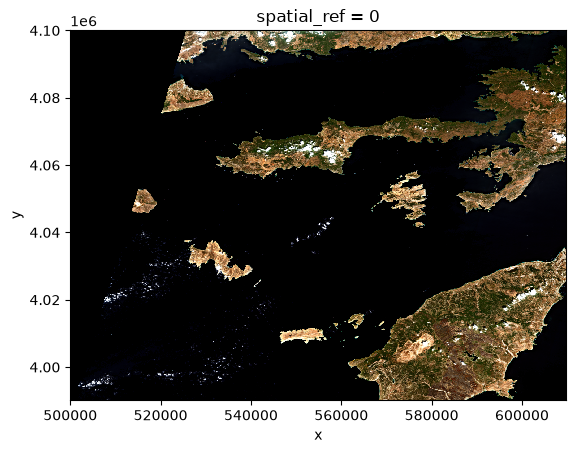

In [28]:
rhodes_visual.plot.imshow()

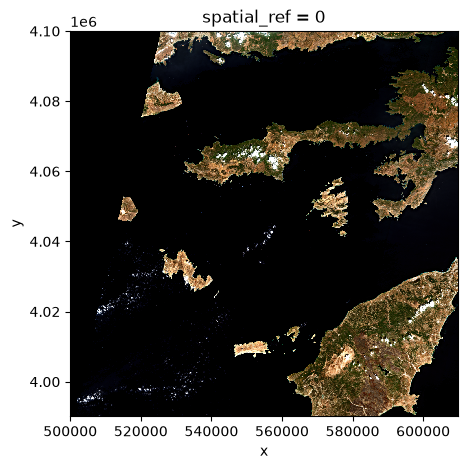

In [30]:
rhodes_visual.plot.imshow(size=5, aspect=1)